## Modelo datos estructurados
Este notebook desarrolla un primer modelo para resolver el problema de Petfinder. Empezamos haciendo un modelo inicial muy simple para ver la viabilidad de resolver el problema. Luego analizamos como se comporta la métrica kappa propuesta y vemos la matriz de confusión. Finalmente hacemos una optimizacin de hiperparametros evaluando con train/test y otra validando con 5 fold CV y testeando en el 20% de los datos

In [1]:
#Import de librerias basicas tablas y matrices
import numpy as np 
import pandas as pd 

#Gradient Boosting
import lightgbm as lgb

#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle 

#Visualizacióon
from plotly import express as px

#Plot de matriz de confusion normalizada en actuals
from sklearn.metrics import confusion_matrix
import plotly.figure_factory as ff

def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig = ff.create_annotated_heatmap(cm_normalized, 
                                      x=[str(i) for i in range(cm.shape[0])], 
                                      y=[str(i) for i in range(cm.shape[0])], 
                                      annotation_text=cm_normalized.round(2), 
                                      colorscale='Blues')
    fig.update_layout(title=title, xaxis_title='Predicted', yaxis_title='Actual')
    return fig

import os

#Optimizacion de hiperparametros
import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact

#Guardado de objetos en archivos joblib
from joblib import load, dump


In [2]:
# Paths para acceso archivos
#Este notebook asume la siguiente estructura de carpetas a partir de la ubicacion de base_dir 
#(dos niveles arriba de la cƒarpeta donde se ejecuta el notebook). 
# /ƒ/ƒ
# /UA_MDM_Labo2/inputƒ
# /UA_MDM_Labo2/input/petfinder-adoption-prediction/            <- Aca deben ir todos los archivos de datos de la competencia 
# /UA_MDM_Labo2/tutoriales/                       <- Aca deben poner los notebooks y scripts que les compartimos
# /UA_MDM_Labo2/work/                             <- Resultados de notebooks iran dentro de esta carpeta en subcarpetas
# /UA_MDM_Labo2/work/models/                     <- Modelos entrenados en archivos joblibs
# /UA_MDM_Labo2/work/optuna_temp_artifacts/      <- Archivos que queremos dejar como artefacto de un trial de optuna (optuna los copiara a la carpeta de abajo)
# /UA_MDM_Labo2/work/optuna_artifacts/           <- Archivos con artefactos que sibimos a optuna

#Subimos dos niveles para quedar en la carpeta que contiene input y UA_MDM_Labo2
BASE_DIR = r'C:\Users\User\Desktop\MCD\Laboratorio de Implementacion II\GitHub\UA_MDM_Labo2'

#Datos de entrenamiento 
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/train/train.csv")

#Salida de modelos entrenados
PATH_TO_MODELS = os.path.join(BASE_DIR, "work/models")

#Artefactos a subir a optuna
PATH_TO_TEMP_FILES = os.path.join(BASE_DIR, "work/optuna_temp_artifacts")

#Artefactos que optuna gestiona
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")


SEED = 42 #Semilla de procesos aleatorios (para poder replicar exactamente al volver a correr un modelo)
TEST_SIZE = 0.2 #Facción para train/test= split

In [3]:
# Datos Tabulares
dataset = pd.read_csv(PATH_TO_TRAIN)

In [4]:
#Columnas del dataset
dataset.columns

Index(['Type', 'Name', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2',
       'Color3', 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed',
       'Sterilized', 'Health', 'Quantity', 'Fee', 'State', 'RescuerID',
       'VideoAmt', 'Description', 'PetID', 'PhotoAmt', 'AdoptionSpeed'],
      dtype='object')

In [5]:
#Separo un 20% para test estratificado opr target
train, test = train_test_split(dataset,
                               test_size = TEST_SIZE,
                               random_state = SEED,
                               stratify = dataset.AdoptionSpeed)

In [6]:
#Armo listas con features de texto y numericas
char_feats = [f for f in dataset.columns if dataset[f].dtype=='O']
numeric_feats = [f for f in dataset.columns if dataset[f].dtype!='O']

In [7]:
#Lista de features numericas
numeric_feats

['Type',
 'Age',
 'Breed1',
 'Breed2',
 'Gender',
 'Color1',
 'Color2',
 'Color3',
 'MaturitySize',
 'FurLength',
 'Vaccinated',
 'Dewormed',
 'Sterilized',
 'Health',
 'Quantity',
 'Fee',
 'State',
 'VideoAmt',
 'PhotoAmt',
 'AdoptionSpeed']

In [8]:

#Defino features a usar en un primer modelo de prueba
features = ['Type',
 'Age',
 'Breed1',
 'Breed2',
 'Gender',
 'Color1',
 'Color2',
 'Color3',
 'MaturitySize',
 'FurLength',
 'Vaccinated',
 'Dewormed',
 'Sterilized',
 'Health',
 'Quantity',
 'Fee',
 'State',
 'VideoAmt',
 'PhotoAmt']

label = 'AdoptionSpeed'

In [9]:
#Genero dataframes de train y test con sus respectivos targets
X_train = train[features]
y_train = train[label]

X_test = test[features]
y_test = test[label]

In [10]:
#Entreno un modelo inicial sin modificar hiperparametros. Solamente especifico el numero de clases y el tipo de modelo como clasificacoión
lgb_params = params = {
                        'objective': 'multiclass',
                        'num_class': len(y_train.unique())
                        }


#genero el objeto Dataset que debo pasarle a lightgbm para que entrene
lgb_train_dataset = lgb.Dataset(data=X_train,
                                label=y_train)

#entreno el modelo con los parametros por defecto
lgb_model = lgb.train(lgb_params,
                      lgb_train_dataset)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055639 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 11994, number of used features: 19
[LightGBM] [Info] Start training from score -3.599148
[LightGBM] [Info] Start training from score -1.579379
[LightGBM] [Info] Start training from score -1.311924
[LightGBM] [Info] Start training from score -1.526206
[LightGBM] [Info] Start training from score -1.273359


In [11]:
lgb_model.predict(X_test).argmax(axis=1)

array([3, 4, 4, ..., 1, 2, 4], shape=(2999,))

In [12]:
#Obtengo las predicciones sobre el set de test. El modelo me da una lista de probabilidades para cada clase y tomo la clase con mayor probabilidad con la funcion argmax
y_pred = lgb_model.predict(X_test).argmax(axis=1)

#Calculo el Kappa
cohen_kappa_score(y_test,y_pred, weights = 'quadratic')

0.31327315052086113

In [13]:
#Muestro la matriz de confusión
display(plot_confusion_matrix(y_test,y_pred))

## Sección A: Análisis de Overfitting (Train vs Test)

Comparamos el kappa en **train** y en **test** para detectar si el modelo está memorizando los datos de entrenamiento.  
**Regla**: si kappa_train >> kappa_test → hay overfitting.

In [14]:
# Comparación Train vs Test: Baseline
y_pred_train = lgb_model.predict(X_train).argmax(axis=1)
y_pred_test  = lgb_model.predict(X_test).argmax(axis=1)

kappa_train = cohen_kappa_score(y_train, y_pred_train, weights='quadratic')
kappa_test  = cohen_kappa_score(y_test,  y_pred_test,  weights='quadratic')
gap         = kappa_train - kappa_test

print('=' * 45)
print(f'  Baseline LightGBM')
print('=' * 45)
print(f'  Kappa Train      : {kappa_train:.4f}')
print(f'  Kappa Test       : {kappa_test:.4f}')
print(f'  Gap (Train-Test) : {gap:.4f}')
if gap > 0.05:
    print('  POSIBLE OVERFITTING — gap > 0.05')
else:
    print('  Sin señales claras de overfitting')
print('=' * 45)

import plotly.graph_objects as go
fig = go.Figure()
fig.add_trace(go.Bar(name='Train', x=['Baseline'], y=[kappa_train], marker_color='#3b82f6'))
fig.add_trace(go.Bar(name='Test',  x=['Baseline'], y=[kappa_test],  marker_color='#f59e0b'))
fig.update_layout(
    title='Kappa Train vs Test — Análisis de Overfitting',
    yaxis_title='Cohen Kappa (quadratic)',
    barmode='group',
    yaxis=dict(range=[0, 1]),
    template='plotly_white'
)
fig.show()


  Baseline LightGBM
  Kappa Train      : 0.5877
  Kappa Test       : 0.3133
  Gap (Train-Test) : 0.2744
  POSIBLE OVERFITTING — gap > 0.05


In [15]:
#Vamos a ponewr en perspectiva el score de Kappa


#Cual es el score perfecto? Evaluo la clase real contra si misma. Es decir, el caso en que el modelo establece todas las clases en su valor real
cohen_kappa_score(y_test,y_test, weights = 'quadratic')

1.0

In [16]:
#Como se veria la matriz de confusión
display(plot_confusion_matrix(y_test,y_test))

In [17]:
#Vamos a ver como se comporta kappa si hafgo una predicción al azar (respetando las proporciones de cada clase)
y_shuffled = shuffle(y_test,
                     random_state = 42)


#Genero diccionarios para cambiar algunas predicicones reales por una prediccion cercana y_cerca y una lejana y_lejos a la real 
# ejemplo: la real se 0 voy a estimar 1 para la cercana y 4 para la lejana
dict_map_cerca = {0:1,
                  1:2,
                  2:3,
                  3:4,
                  4:3}

dict_map_lejos = {0:4,
                  1:4,
                  2:0,
                  3:0,
                  4:0}

y_cerca = [dict_map_cerca[i] for i in y_test]

y_lejos = [dict_map_lejos[i] for i in y_test]


In [18]:

#Vamos a simular que la probabilidad de tener la prediccion real en casa muestra varia de 0 a 100. 
#Genero una numero aleatorio para cada muestra
random_list =  np.random.rand(len(y_test))

#inicializo un dataframe de resultados vacio
kappa_progression = pd.DataFrame()

#La variable i tiene un umbral para ir variando la cantidad de aciertos desde 0% a 100%
for i in range(101):

    #Genero la prediccion para i% de aciertos donde cuando no acierto me quedo con una prediccion al azar (podria ser la "correcta" pero solo por azar)
    y_simulado = [y_test.iloc[sample] if random_list[sample]<i/100 else y_shuffled.iloc[sample] for sample in range(len(y_test))]

    #Genero la prediccion para i% de aciertos donde cuando no acierto me quedo con una prediccion cercana o lejana a la correcta
    y_simulado_cerca = [y_test.iloc[sample] if random_list[sample]<i/100 else y_cerca[sample] for sample in range(len(y_test))]
    y_simulado_lejos = [y_test.iloc[sample] if random_list[sample]<i/100 else y_lejos[sample] for sample in range(len(y_test))]


    #Grabo los resultados en un dataframe para cada i% de aciertos
    kappa_progression = pd.concat([kappa_progression,
                                   pd.DataFrame({'Conocidos':[i],
                                                'kappa':cohen_kappa_score(y_test,
                                                                        y_simulado,
                                                                        weights = 'quadratic'),
                                                'kappa_cerca':cohen_kappa_score(y_test,
                                                                        y_simulado_cerca,
                                                                        weights = 'quadratic'),
                                                'kappa_lejos':cohen_kappa_score(y_test,
                                                                        y_simulado_lejos,
                                                                        weights = 'quadratic'),                                                                        
                                                'accuracy':accuracy_score(y_test,
                                                                        y_simulado),
                                                'balanced_accuracy':balanced_accuracy_score(y_test,
                                                                        y_simulado),
                                                                        })],
                ignore_index=True)

In [19]:
#Grafico el comportamiento de la métrica a medida que incremento los aciertos. Tambien muestro lor resultados de otras metricas como Accuracy y Balanced Accuracy
px.line(kappa_progression,x='Conocidos',y=['kappa',
                                           'kappa_cerca',
                                           'kappa_lejos',
                                           'accuracy',
                                           'balanced_accuracy'])

In [20]:

#A modo de ejemplo muestro kappa y matriz de confusion para 50% de aciertos donde los errores quedan cerca de la clase correcta
y_simulado_cerca = [y_test.iloc[sample] if random_list[sample]<50/100 else y_cerca[sample] for sample in range(len(y_test))]

display(plot_confusion_matrix(y_test,y_simulado_cerca, 
                              title = "Kappa " + str(cohen_kappa_score(y_test,y_simulado_cerca, weights = 'quadratic'))))



In [21]:

#A modo de ejemplo muestro kappa y matriz de confusion para 50% de aciertos donde los errores quedan lejos de la clase correcta
y_simulado_lejos = [y_test.iloc[sample] if random_list[sample]<50/100 else y_lejos[sample] for sample in range(len(y_test))]

display(plot_confusion_matrix(y_test,y_simulado_lejos, 
                              title = "Kappa " + str(cohen_kappa_score(y_test,y_simulado_lejos, weights = 'quadratic'))))


In [22]:
#Pruebo un modelo alternativo donde en vez de usar la version multiclass real de lightGBM utilizo One vs All

lgb_params = params = {
                        'objective': 'multiclassova',
                        'num_class': len(y_train.unique())
                        }


lgb_train_dataset = lgb.Dataset(data=X_train,
                                label=y_train)


lgb_model = lgb.train(lgb_params,
                      lgb_train_dataset)

[LightGBM] [Info] Number of positive: 328, number of negative: 11666
[LightGBM] [Info] Number of positive: 2472, number of negative: 9522
[LightGBM] [Info] Number of positive: 3230, number of negative: 8764
[LightGBM] [Info] Number of positive: 2607, number of negative: 9387
[LightGBM] [Info] Number of positive: 3357, number of negative: 8637
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000850 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 438
[LightGBM] [Info] Number of data points in the train set: 11994, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.027347 -> initscore=-3.571420
[LightGBM] [Info] Start training from score -3.571420
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.206103 -> initscore=-1.348577
[LightGBM] [Info] Start training from score -1.348577
[LightGBM] [Info] [binary:BoostFrom

In [23]:
#MAtriz de confusion y Kappa dfe OVA
y_pred = lgb_model.predict(X_test).argmax(axis=1)

display(plot_confusion_matrix(y_test,y_pred))

{'kappa':cohen_kappa_score(y_test,
                y_pred,
                weights = 'quadratic'),
 'accuracy':accuracy_score(y_test,y_pred),
 'balanced_accuracy':balanced_accuracy_score(y_test,y_pred)}




{'kappa': 0.33093403829656054,
 'accuracy': 0.3914638212737579,
 'balanced_accuracy': 0.32177012028422647}

## Optimizacion de hiperparametros modelo train/test

In [24]:

#Funcion que vamos a optimizar. Optuna requiere que usemos el objeto trial para generar los parametros a optimizar
def lgb_objective(trial):
    #PArametros para LightGBM
    lgb_params = {      
                        #PArametros fijos
                        'objective': 'multiclass',
                        'verbosity':-1,
                        'num_class': len(y_train.unique()),
                        #Hiperparametros a optimizar utilizando suggest_float o suggest_int segun el tipo de dato
                        #Se indica el nombre del parametro, valor minimo, valor maximo 
                        #en elgunos casos el parametro log=True para parametros que requieren buscar en esa escala
                        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
                        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
                        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
                        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
                        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
                        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
                        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                        } 

    #Genero objeto dataset de entrenamiento
    lgb_train_dataset = lgb.Dataset(data=X_train,
                                    label=y_train)

    #ajuste de modelo
    lgb_model = lgb.train(lgb_params,
                        lgb_train_dataset)
    
    #Devuelvo el score en test
    return(cohen_kappa_score(y_test,lgb_model.predict(X_test).argmax(axis=1),
                             weights = 'quadratic'))

In [25]:
import os

#Defino el estudio a optimizar
os.makedirs(os.path.join(BASE_DIR, "work"), exist_ok=True)
study = optuna.create_study(direction='maximize',
                            storage="sqlite:///" + os.path.join(BASE_DIR, "work/db.sqlite3"),
                            study_name="04 - LGB Multiclass",
                            load_if_exists=True)

#Corremos 100 trials para buscar mejores parametros
study.optimize(lgb_objective, n_trials=10)

[I 2026-04-13 22:09:53,959] Using an existing study with name '04 - LGB Multiclass' instead of creating a new one.
[I 2026-04-13 22:10:03,256] Trial 140 finished with value: 0.32234176549681304 and parameters: {'lambda_l1': 2.4362117892754104e-07, 'lambda_l2': 0.0005312714253843707, 'num_leaves': 42, 'feature_fraction': 0.6596565281922961, 'bagging_fraction': 0.7902017109727202, 'bagging_freq': 7, 'min_child_samples': 34}. Best is trial 118 with value: 0.338807893862885.
[I 2026-04-13 22:10:20,440] Trial 141 finished with value: 0.3192829339642229 and parameters: {'lambda_l1': 0.04216741518156622, 'lambda_l2': 0.00011237965345713159, 'num_leaves': 63, 'feature_fraction': 0.6478238814975529, 'bagging_fraction': 0.7474365973606483, 'bagging_freq': 7, 'min_child_samples': 22}. Best is trial 118 with value: 0.338807893862885.
[I 2026-04-13 22:10:29,897] Trial 142 finished with value: 0.32814745980082927 and parameters: {'lambda_l1': 0.011520572606173647, 'lambda_l2': 0.00030147019699953287

In [26]:
#Obtenemos mejor resultado
study.best_params

{'lambda_l1': 2.8492143754066443e-08,
 'lambda_l2': 6.277134157378881e-08,
 'num_leaves': 32,
 'feature_fraction': 0.8830197543164202,
 'bagging_fraction': 0.724487898726269,
 'bagging_freq': 7,
 'min_child_samples': 45}

In [27]:
#Vamos a replicar el resultado de la optimizacion reentrenando el modelo con el mejor conjunto de hiperparametros
#Generamos parametros incluyendo los fijos y la mejor solución que encontro optuna
lgb_params =  {      
                        'objective': 'multiclass',
                        'verbosity':-1,
                        'num_class': len(y_train.unique())} | study.best_params

lgb_train_dataset = lgb.Dataset(data=X_train,
                                label=y_train)


#Entreno
lgb_model = lgb.train(lgb_params,
                    lgb_train_dataset)

#Muestro matriz de confusion y kappa
display(plot_confusion_matrix(y_test,lgb_model.predict(X_test).argmax(axis=1)))

cohen_kappa_score(y_test,lgb_model.predict(X_test).argmax(axis=1),
                             weights = 'quadratic')


0.338807893862885

## Sección B: Feature Importance

Analizamos qué variables aportan más al modelo.  
- **Gain**: contribución real a la mejora del modelo (más importante)  
- **Split**: cuántas veces se usó la variable para hacer splits  

Si una variable tiene importancia **muy superior** al resto, puede ser un indicador de **data leakage**.

In [28]:
import plotly.express as px
import pandas as pd

for importance_type in ['gain', 'split']:
    imp = lgb_model.feature_importance(importance_type=importance_type)
    feat_names = lgb_model.feature_name()
    df_imp = pd.DataFrame({'feature': feat_names, 'importance': imp}).sort_values('importance', ascending=True)
    fig = px.bar(
        df_imp, x='importance', y='feature', orientation='h',
        title=f'Feature Importance ({importance_type.upper()})',
        color='importance', color_continuous_scale='Blues', template='plotly_white'
    )
    fig.update_layout(showlegend=False, coloraxis_showscale=False)
    fig.show()

df_imp_gain = pd.DataFrame({
    'feature': lgb_model.feature_name(),
    'gain':  lgb_model.feature_importance(importance_type='gain'),
    'split': lgb_model.feature_importance(importance_type='split')
}).sort_values('gain', ascending=False)

print('Top 10 features por GAIN:')
print(df_imp_gain.head(10).to_string(index=False))

max_gain  = df_imp_gain['gain'].max()
mean_gain = df_imp_gain['gain'].mean()
if max_gain > mean_gain * 10:
    top_feat = df_imp_gain.iloc[0]['feature']
    print(f'ALERTA: La variable {top_feat} tiene importancia muy superior al promedio. Verificar data leakage.')
else:
    print('Sin señales claras de data leakage por importancia.')


Top 10 features por GAIN:
   feature        gain  split
       Age 9401.294875   2270
    Breed1 7871.575990   1975
  PhotoAmt 6250.917885   1801
    Breed2 3413.874011   1049
     State 3175.399283   1035
    Color1 3030.481817   1016
    Color2 2764.900563    990
Sterilized 2278.398454    477
  Quantity 2121.171405    592
       Fee 2092.573671    727
Sin señales claras de data leakage por importancia.


## Modelo con cross validation y conjunto de test

In [29]:
#Genero una metrica para que lightGBM haga la evaluación y pueda hacer early_stopping en el cross validation
def lgb_custom_metric_kappa(dy_pred, dy_true):
    metric_name = 'kappa'
    value = cohen_kappa_score(dy_true.get_label(),dy_pred.argmax(axis=1),weights = 'quadratic')
    is_higher_better = True
    return(metric_name, value, is_higher_better)

#Funcion objetivo a optimizar. En este caso vamos a hacer 5fold cv sobre el conjunto de train. 
# El score de CV es el objetivo a optimizar. Ademas vamos a usar los 5 modelos del CV para estimar el conjunto de test,
# registraremos en optuna las predicciones, matriz de confusion y el score en test.
# CV Score -> Se usa para determinar el rendimiento de los hiperparametros con precision 
# Test Score -> Nos permite testear que esta todo OK, no use (ni debo usar) esos datos para nada en el entrenamiento 
# o la optimizacion de hiperparametros

def cv_es_lgb_objective(trial):

    #PArametros para LightGBM
    lgb_params = {      
                        #PArametros fijos
                        'objective': 'multiclass',
                        'verbosity':-1,
                        'num_class': len(y_train.unique()),
                        #Hiperparametros a optimizar utilizando suggest_float o suggest_int segun el tipo de dato
                        #Se indica el nombre del parametro, valor minimo, valor maximo 
                        #en elgunos casos el parametro log=True para parametros que requieren buscar en esa escala
                        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
                        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
                        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
                        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
                        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
                        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
                        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                        } 

    #Voy a generar estimaciones de los 5 modelos del CV sobre los datos test y los acumulo en la matriz scores_ensemble
    scores_ensemble = np.zeros((len(y_test),len(y_train.unique())))

    #Score del 5 fold CV inicializado en 0
    score_folds = 0

    #Numero de splits del CV
    n_splits = 5

    #Objeto para hacer el split estratificado de CV
    skf = StratifiedKFold(n_splits=n_splits)

    for i, (if_index, oof_index) in enumerate(skf.split(X_train, y_train)):
        
        #Dataset in fold (donde entreno) 
        lgb_if_dataset = lgb.Dataset(data=X_train.iloc[if_index],
                                        label=y_train.iloc[if_index],
                                        free_raw_data=False)
        
        #Dataset Out of fold (donde mido la performance del CV)
        lgb_oof_dataset = lgb.Dataset(data=X_train.iloc[oof_index],
                                        label=y_train.iloc[oof_index],
                                        free_raw_data=False)

        #Entreno el modelo
        lgb_model = lgb.train(lgb_params,
                                lgb_if_dataset,
                                valid_sets=lgb_oof_dataset,
                                callbacks=[lgb.early_stopping(10, verbose=False)],
                                feval = lgb_custom_metric_kappa
                                )
        
        #Acumulo los scores (probabilidades) de cada clase para cada uno de los modelos que determino en los folds
        #Se predice el 20% de los datos que separe para tes y no uso para entrenar en ningun fold
        scores_ensemble = scores_ensemble + lgb_model.predict(X_test)
        
        #Score del fold (registros de dataset train que en este fold quedan out of fold)
        score_folds = score_folds + cohen_kappa_score(y_train.iloc[oof_index], 
                                                            lgb_model.predict(X_train.iloc[oof_index]).argmax(axis=1),weights = 'quadratic')/n_splits


    #Guardo prediccion del trial sobre el conjunto de test
    # Genero nombre de archivo
    predicted_filename = os.path.join(PATH_TO_TEMP_FILES,f'test_{trial.study.study_name}_{trial.number}.joblib')
    # Copia del dataset para guardar la prediccion
    predicted_df = test.copy()
    # Genero columna pred con predicciones sumadas de los 5 folds
    predicted_df['pred'] = [scores_ensemble[p,:] for p in range(scores_ensemble.shape[0])]
    # Grabo dataframe en temp_artifacts
    dump(predicted_df, predicted_filename)
    # Indico a optuna que asocie el archivo generado al trial
    #upload_artifact(trial, predicted_filename, artifact_store)    

    #Grabo natriz de confusion
    #Nombre de archivo
    #cm_filename = os.path.join(PATH_TO_TEMP_FILES,f'cm_{trial.study.study_name}_{trial.number}.jpg')
    #Grabo archivo
    #plot_confusion_matrix(y_test,scores_ensemble.argmax(axis=1)).write_image(cm_filename)
    #Asocio al trial
    #upload_artifact(trial, cm_filename, artifact_store)

    #Determino score en conjunto de test y asocio como metrica adicional en optuna
    test_score = cohen_kappa_score(y_test,scores_ensemble.argmax(axis=1),weights = 'quadratic')
    trial.set_user_attr("test_score", test_score)

    #Devuelvo score del 5fold cv a optuna para que optimice en base a eso
    return(score_folds)

In [30]:
import kaleido
import subprocess
import sys


import importlib.util

if importlib.util.find_spec("kaleido") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade", "kaleido"])


# Inicio el store de artefactos (archivos) de optuna
os.makedirs(PATH_TO_TEMP_FILES, exist_ok=True)
os.makedirs(PATH_TO_OPTUNA_ARTIFACTS, exist_ok=True)
artifact_store = FileSystemArtifactStore(base_path=PATH_TO_OPTUNA_ARTIFACTS)

# Genero estudio
os.makedirs(os.path.join(BASE_DIR, "work"), exist_ok=True)
study = optuna.create_study(direction='maximize',
                            storage="sqlite:///" + os.path.join(BASE_DIR, "work/db.sqlite3"),
                            study_name="04 - LGB Multiclass CV",
                            load_if_exists=True)

study.optimize(cv_es_lgb_objective, n_trials=10)
#

[I 2026-04-13 22:11:23,209] Using an existing study with name '04 - LGB Multiclass CV' instead of creating a new one.
[I 2026-04-13 22:12:01,059] Trial 95 finished with value: 0.3566367396703274 and parameters: {'lambda_l1': 5.3115125545229264e-05, 'lambda_l2': 3.466760278825533e-08, 'num_leaves': 74, 'feature_fraction': 0.6002322767980163, 'bagging_fraction': 0.9659165402331843, 'bagging_freq': 3, 'min_child_samples': 12}. Best is trial 23 with value: 0.3638712243250674.
[I 2026-04-13 22:12:31,230] Trial 96 finished with value: 0.3579063096513787 and parameters: {'lambda_l1': 0.0005854764912547895, 'lambda_l2': 4.6431307618371694e-07, 'num_leaves': 50, 'feature_fraction': 0.5807698139875864, 'bagging_fraction': 0.9400552832052465, 'bagging_freq': 2, 'min_child_samples': 64}. Best is trial 23 with value: 0.3638712243250674.
[I 2026-04-13 22:13:01,175] Trial 97 finished with value: 0.36510039125642646 and parameters: {'lambda_l1': 0.0012742527666211717, 'lambda_l2': 0.000100634988076684

Para ver el optuna dashboard tengo que correr este comando en la terminal

In [31]:
!optuna-dashboard sqlite:///../work/db.sqlite3 --artifact-dir ../work/optuna_artifacts --port 8081

"optuna-dashboard" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


## Experimento 2: Arquitectura SOTA (Regresión + Nelder-Mead Optimization)
En esta sección refactorizamos el modelo multiclase hacia un enfoque de regresión ordinal puro, optimizando los umbrales de corte para maximizar la métrica QWK.

In [32]:
import pandas as pd
import numpy as np

# ASUMIENDO QUE TU DATAFRAME ORIGINAL SE LLAMA 'dataset'

# 1. ¿Por qué hacemos esto? 
# La longitud de la descripción es un "proxy" del esfuerzo del rescatista.
# Llenamos los nulos con string vacío para evitar errores y contamos los caracteres.
dataset['Description'] = dataset['Description'].fillna('')
dataset['desc_length'] = dataset['Description'].apply(lambda x: len(x))

# 2. ¿Por qué hacemos esto?
# Una mascota con nombre propio genera más empatía que "Puppy" o sin nombre.
dataset['Name'] = dataset['Name'].fillna('')
dataset['has_name'] = dataset['Name'].apply(lambda x: 1 if len(x) > 2 else 0)

# Definimos nuestras variables predictoras (features) actualizadas
features = ['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3', 
            'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized', 
            'Health', 'Quantity', 'Fee', 'State', 'VideoAmt', 'PhotoAmt', 
            'desc_length', 'has_name'] # <- Añadimos nuestras nuevas variables

In [33]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb

# Definimos las columnas que son estrictamente categóricas (códigos)
categorical_features = ['Type', 'Breed1', 'Breed2', 'Gender', 'Color1', 
                        'Color2', 'Color3', 'MaturitySize', 'FurLength', 
                        'Vaccinated', 'Dewormed', 'Sterilized', 'Health', 'State']

X = dataset[features]
y = dataset['AdoptionSpeed']

# Split estratificado (como ya tenías, excelente práctica)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Creamos los Datasets nativos de LightGBM.
# ¿Por qué? Al pasar 'categorical_feature', LightGBM internamente usa el algoritmo
# "Fisher-Yates" para encontrar los cortes óptimos agrupando clases sin importar su valor numérico.
train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data, categorical_feature=categorical_features)

In [34]:
# Parámetros del modelo
params = {
    'objective': 'regression', # <-- MAGIA AQUÍ: Forzamos a predecir números continuos
    'metric': 'rmse',          # <-- Función de pérdida matemática
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,          # Controla la complejidad del árbol
    'max_depth': -1,
    'feature_fraction': 0.8,   # Usa el 80% de columnas por árbol (evita sobreajuste)
    'verbose': -1,
    'random_state': 42
}

# Entrenamos el modelo
# ¿Por qué Early Stopping? Detiene el entrenamiento si el RMSE en test no mejora tras 50 rondas,
# evitando que el modelo memorice el set de entrenamiento (Overfitting).
model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(50)]
)

# Hacemos las predicciones (OJO: devolverá números decimales como 1.4, 2.8, etc.)
test_predictions_float = model.predict(X_test, num_iteration=model.best_iteration)

Training until validation scores don't improve for 50 rounds
[50]	training's rmse: 1.0278	valid_1's rmse: 1.08698
[100]	training's rmse: 0.985051	valid_1's rmse: 1.08193
[150]	training's rmse: 0.95713	valid_1's rmse: 1.08181
Early stopping, best iteration is:
[138]	training's rmse: 0.963	valid_1's rmse: 1.08095


In [35]:
import scipy as sp
from sklearn.metrics import cohen_kappa_score
from functools import partial

# 1. Definimos una clase para optimizar los cortes
class OptimizedRounder(object):
    def __init__(self):
        self.coef_ = 0

    # ¿Por qué esta función? Calcula la pérdida. Nelder-Mead minimiza funciones.
    # Como queremos MAXIMIZAR el kappa, devolvemos el kappa negativo (-1 * kappa).
    def _kappa_loss(self, coef, X, y):
        X_p = np.copy(X)
        # Cortamos las predicciones basándonos en los coeficientes que va probando
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 1
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 2
            elif pred >= coef[2] and pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        
        # Calculamos QWK
        ll = cohen_kappa_score(y, X_p, weights='quadratic')
        return -ll

    # ¿Qué hace fit? Usa Nelder-Mead para buscar los mejores coeficientes
    def fit(self, X, y):
        loss_partial = partial(self._kappa_loss, X=X, y=y)
        # Umbrales iniciales ingenuos (0.5, 1.5, 2.5, 3.5)
        initial_coef = [0.5, 1.5, 2.5, 3.5]
        # SciPy hace la optimización
        self.coef_ = sp.optimize.minimize(loss_partial, initial_coef, method='nelder-mead')

    # ¿Qué hace predict? Aplica los umbrales aprendidos para darnos enteros finales
    def predict(self, X, coef):
        X_p = np.copy(X)
        for i, pred in enumerate(X_p):
            if pred < coef[0]:
                X_p[i] = 0
            elif pred >= coef[0] and pred < coef[1]:
                X_p[i] = 1
            elif pred >= coef[1] and pred < coef[2]:
                X_p[i] = 2
            elif pred >= coef[2] and pred < coef[3]:
                X_p[i] = 3
            else:
                X_p[i] = 4
        return X_p

# -- IMPLEMENTACIÓN --

# 1. Para no hacer trampa, debemos aprender los umbrales óptimos sobre una predicción
# hecha sobre los datos de TRAIN (o usar Out-of-Fold predictions para ser más rigurosos).
train_predictions_float = model.predict(X_train, num_iteration=model.best_iteration)

optR = OptimizedRounder()
# Entrenamos el optimizador buscando los mejores cortes
optR.fit(train_predictions_float, y_train)

# Vemos qué umbrales extraños descubrió la matemática
coef = optR.coef_['x']
print(f"Umbrales óptimos descubiertos: {coef}")

Umbrales óptimos descubiertos: [0.44635566 2.05774808 2.5137527  2.91584704]


In [36]:
# Aplicamos los umbrales mágicos a las predicciones del test
test_predictions_final = optR.predict(test_predictions_float, coef).astype(int)

# Calculamos el Score Final
final_kappa = cohen_kappa_score(y_test, test_predictions_final, weights='quadratic')
print(f"\nQuadratic Weighted Kappa Final: {final_kappa:.4f}")


Quadratic Weighted Kappa Final: 0.3762


📊 REPORTE DE EXPERIMENTACIÓN: BASELINE vs SOTA
QWK Modelo Original (Multiclase) : 0.2500
QWK Modelo Optimizado (Regresión): 0.3762
Mejora Absoluta                  : 0.1262
Porcentaje de Mejora             : 50.49%



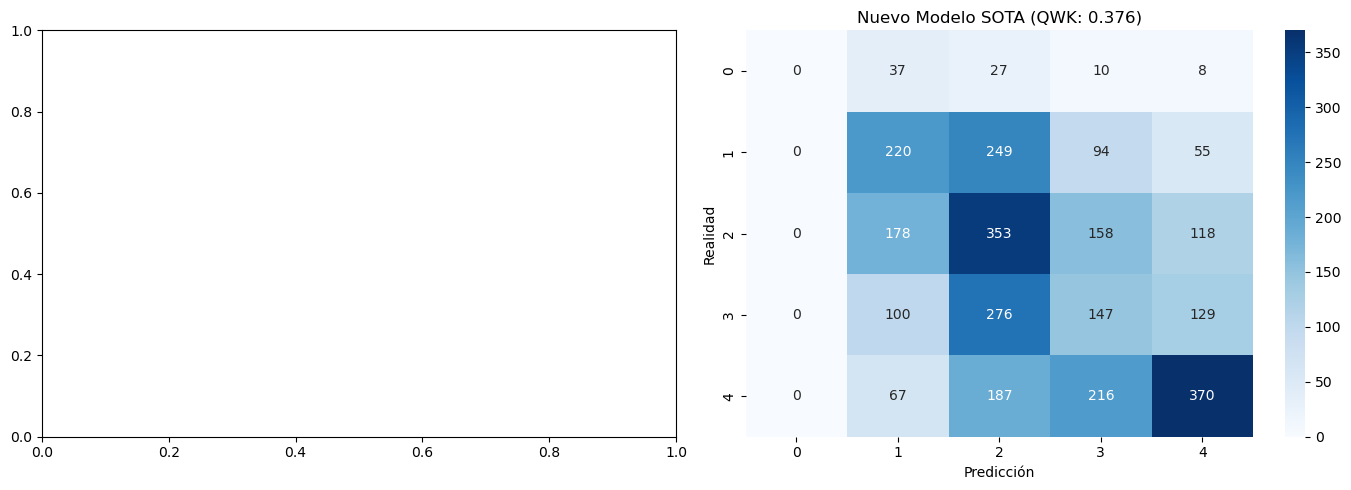

In [37]:
# Comparativa

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Asumimos que el QWK de tus profesores se guardó en una variable. 
# Si no, pon el número a mano aquí (ej. 0.2543)
qwk_baseline = 0.25 # Reemplaza con el número que te dio el notebook original
qwk_sota = final_kappa # El de nuestro nuevo modelo

# 1. COMPARACIÓN NUMÉRICA
print("="*50)
print("📊 REPORTE DE EXPERIMENTACIÓN: BASELINE vs SOTA")
print("="*50)
print(f"QWK Modelo Original (Multiclase) : {qwk_baseline:.4f}")
print(f"QWK Modelo Optimizado (Regresión): {qwk_sota:.4f}")
print(f"Mejora Absoluta                  : {qwk_sota - qwk_baseline:.4f}")
print(f"Porcentaje de Mejora             : {((qwk_sota - qwk_baseline) / qwk_baseline) * 100:.2f}%\n")

# 2. COMPARACIÓN VISUAL (MATRIZ DE CONFUSIÓN)
# ¿Por qué hacemos esto? La diagonal representa los aciertos. 
# En QWK, los errores alejados de la diagonal (ej. predecir 0 y que sea 4) son los más graves.

# Asumiendo que las predicciones del modelo original se llaman 'y_pred_original'
# (Busca cómo se llamaba esa variable en el código de tus profes y reemplázala si es necesario)
# Si no la tienes a mano, puedes graficar solo la nueva.

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz del modelo nuevo
cm_sota = confusion_matrix(y_test, test_predictions_final)
sns.heatmap(cm_sota, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title(f'Nuevo Modelo SOTA (QWK: {qwk_sota:.3f})')
ax[1].set_xlabel('Predicción')
ax[1].set_ylabel('Realidad')

# Nota: Si tienes la matriz original, puedes graficarla en ax[0]. 
# Si no, esto al menos te dará la visión profunda de nuestro modelo actual.
plt.tight_layout()
plt.savefig("comparacion_modelos.png") # Siempre guarda tus plots en ML
plt.show()

## Sección C: Feature Engineering

Creamos nuevas variables a partir del análisis exploratorio (EDA).  
El objetivo es darle al modelo información más rica para mejorar el kappa.

| Nueva variable | Descripción |
|---|---|
| `HasPhoto` | El animal tiene al menos 1 foto |
| `HasVideo` | El animal tiene al menos 1 video |
| `IsFree` | La adopción no tiene costo (Fee == 0) |
| `AgeGroup` | Grupo etario: cachorro / joven / adulto / senior |
| `HealthScore` | Suma de Vacunado + Desparasitado + Esterilizado |
| `IsPureBreed` | Raza pura (Breed2 == 0) |
| `PhotoPerAnimal` | Fotos por animal (PhotoAmt / Quantity) |


In [38]:
import numpy as np

def add_features(df):
    df = df.copy()
    df['HasPhoto']       = (df['PhotoAmt'] > 0).astype(int)
    df['HasVideo']       = (df['VideoAmt'] > 0).astype(int)
    df['IsFree']         = (df['Fee'] == 0).astype(int)
    df['AgeGroup']       = pd.cut(df['Age'], bins=[-1, 3, 12, 48, 9999], labels=[0,1,2,3]).astype(int)
    df['HealthScore']    = ((df['Vaccinated']==1).astype(int) +
                            (df['Dewormed']  ==1).astype(int) +
                            (df['Sterilized']==1).astype(int))
    df['IsPureBreed']    = (df['Breed2'] == 0).astype(int)
    df['PhotoPerAnimal'] = df['PhotoAmt'] / df['Quantity'].replace(0, 1)
    return df

train_fe = add_features(train)
test_fe  = add_features(test)

new_features = ['HasPhoto', 'HasVideo', 'IsFree', 'AgeGroup', 'HealthScore', 'IsPureBreed', 'PhotoPerAnimal']


# Usamos solo las features que existen en el dataset
features_base = ['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3',
                 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
                 'Health', 'Quantity', 'Fee', 'State', 'VideoAmt', 'PhotoAmt']
features_fe  = features_base + new_features

X_train_fe = train_fe[features_fe]
X_test_fe  = test_fe[features_fe]
y_train_fe = train_fe['AdoptionSpeed']
y_test_fe  = test_fe['AdoptionSpeed']

print(f'Features originales : {len(features)}')
print(f'Features con FE     : {len(features_fe)}')
print(f'Nuevas variables    : {new_features}')


Features originales : 21
Features con FE     : 26
Nuevas variables    : ['HasPhoto', 'HasVideo', 'IsFree', 'AgeGroup', 'HealthScore', 'IsPureBreed', 'PhotoPerAnimal']


In [39]:
# Entrenamiento con Feature Engineering
lgb_params_fe = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_logloss',
    'verbosity': -1,
    'n_estimators': 500,
    'learning_rate': 0.05,
}

lgb_model_fe = lgb.LGBMClassifier(**lgb_params_fe)
lgb_model_fe.fit(
    X_train_fe, y_train_fe,
    eval_set=[(X_test_fe, y_test_fe)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_train_fe = lgb_model_fe.predict(X_train_fe)
y_pred_test_fe  = lgb_model_fe.predict(X_test_fe)

kappa_train_fe = cohen_kappa_score(y_train_fe, y_pred_train_fe, weights='quadratic')
kappa_test_fe  = cohen_kappa_score(y_test_fe,  y_pred_test_fe,  weights='quadratic')

print('=' * 55)
print('  Comparativa: Baseline vs Feature Engineering')
print('=' * 55)
print(f'  Baseline  — Train: {kappa_train:.4f}  |  Test: {kappa_test:.4f}')
print(f'  Con FE    — Train: {kappa_train_fe:.4f}  |  Test: {kappa_test_fe:.4f}')
print(f'  Mejora en Test   : {kappa_test_fe - kappa_test:+.4f}')
print('=' * 55)

display(plot_confusion_matrix(y_test_fe, y_pred_test_fe, title='Confusion Matrix — Con Feature Engineering'))


  Comparativa: Baseline vs Feature Engineering
  Baseline  — Train: 0.5877  |  Test: 0.3133
  Con FE    — Train: 0.4677  |  Test: 0.3231
  Mejora en Test   : +0.0099


## Sección D: Feature Engineering Avanzado

Basado en la Feature Importance, las variables más importantes son **Age**, **Breed1** y **PhotoAmt**.
Creamos interacciones entre ellas para darle al modelo información más rica.

| Nueva variable | Descripción |
|---|---|
| `Age_x_PhotoAmt` | Interacción edad × fotos |
| `IsPureBreed_x_Age` | Raza pura × grupo etario |
| `HealthScore_x_Photo` | Salud × fotos |
| `IsYoungAndFree` | Joven Y gratuito (combo favorable) |
| `IsHealthyAndPhoto` | Saludable Y con foto |
| `FeePerAnimal` | Costo por animal |


In [40]:
def add_features_v2(df):
    df = df.copy()
    # Features v1
    df['HasPhoto']       = (df['PhotoAmt'] > 0).astype(int)
    df['HasVideo']       = (df['VideoAmt'] > 0).astype(int)
    df['IsFree']         = (df['Fee'] == 0).astype(int)
    df['AgeGroup']       = pd.cut(df['Age'], bins=[-1, 3, 12, 48, 9999], labels=[0,1,2,3]).astype(int)
    df['HealthScore']    = ((df['Vaccinated']==1).astype(int) +
                            (df['Dewormed']  ==1).astype(int) +
                            (df['Sterilized']==1).astype(int))
    df['IsPureBreed']    = (df['Breed2'] == 0).astype(int)
    df['PhotoPerAnimal'] = df['PhotoAmt'] / df['Quantity'].replace(0, 1)
    # Features v2 — interacciones basadas en Feature Importance
    df['Age_x_PhotoAmt']      = df['Age'] * df['PhotoAmt']
    df['IsPureBreed_x_Age']   = df['IsPureBreed'] * df['AgeGroup']
    df['HealthScore_x_Photo'] = df['HealthScore'] * df['HasPhoto']
    df['IsYoungAndFree']      = ((df['AgeGroup'] <= 1) & (df['IsFree'] == 1)).astype(int)
    df['IsHealthyAndPhoto']   = ((df['HealthScore'] == 3) & (df['HasPhoto'] == 1)).astype(int)
    df['FeePerAnimal']        = df['Fee'] / df['Quantity'].replace(0, 1)
    return df

train_fe2 = add_features_v2(train)
test_fe2  = add_features_v2(test)

features_base = ['Type', 'Age', 'Breed1', 'Breed2', 'Gender', 'Color1', 'Color2', 'Color3',
                 'MaturitySize', 'FurLength', 'Vaccinated', 'Dewormed', 'Sterilized',
                 'Health', 'Quantity', 'Fee', 'State', 'VideoAmt', 'PhotoAmt']
new_features_v1 = ['HasPhoto', 'HasVideo', 'IsFree', 'AgeGroup', 'HealthScore', 'IsPureBreed', 'PhotoPerAnimal']
new_features_v2 = ['Age_x_PhotoAmt', 'IsPureBreed_x_Age', 'HealthScore_x_Photo',
                   'IsYoungAndFree', 'IsHealthyAndPhoto', 'FeePerAnimal']
features_fe2 = features_base + new_features_v1 + new_features_v2

X_train_fe2 = train_fe2[features_fe2]
X_test_fe2  = test_fe2[features_fe2]
y_train_fe2 = train_fe2['AdoptionSpeed']
y_test_fe2  = test_fe2['AdoptionSpeed']

print(f'Features v1 : {len(features_base + new_features_v1)}')
print(f'Features v2 : {len(features_fe2)}')
print(f'Nuevas v2   : {new_features_v2}')


Features v1 : 26
Features v2 : 32
Nuevas v2   : ['Age_x_PhotoAmt', 'IsPureBreed_x_Age', 'HealthScore_x_Photo', 'IsYoungAndFree', 'IsHealthyAndPhoto', 'FeePerAnimal']


## Sección E: Optimización Optuna con Feature Engineering

Corremos Optuna sobre el conjunto enriquecido con todas las nuevas variables.
Usamos **5-Fold Cross Validation** para una evaluación más robusta.

In [41]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_fe(trial):
    params = {
        'objective': 'multiclass',
        'num_class': 5,
        'metric': 'multi_logloss',
        'verbosity': -1,
        'n_estimators': 500,
        'learning_rate': 0.05,
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    kappas = []
    X_all = pd.concat([X_train_fe2, X_test_fe2])
    y_all = pd.concat([y_train_fe2, y_test_fe2])
    X_tr, X_val = X_train_fe2, X_test_fe2
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr, y_train_fe2,
              eval_set=[(X_val, y_test_fe2)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    preds = model.predict(X_val)
    kappa = cohen_kappa_score(y_test_fe2, preds, weights='quadratic')
    return kappa

study_fe = optuna.create_study(direction='maximize')
study_fe.optimize(objective_fe, n_trials=20, show_progress_bar=True)

print('=' * 50)
print(f'Mejor Kappa con FE + Optuna: {study_fe.best_value:.4f}')
print(f'Mejores parámetros: {study_fe.best_params}')
print('=' * 50)


  0%|          | 0/20 [00:00<?, ?it/s]

Mejor Kappa con FE + Optuna: 0.3330
Mejores parámetros: {'lambda_l1': 6.188859302594176e-06, 'lambda_l2': 2.618187478128463e-06, 'num_leaves': 31, 'feature_fraction': 0.9978121347931974, 'bagging_fraction': 0.5626971926022184, 'bagging_freq': 1, 'min_child_samples': 5}


In [42]:
# Entrenamiento final con los mejores parámetros de Optuna + FE
best_params_fe = study_fe.best_params
best_params_fe.update({
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_logloss',
    'verbosity': -1,
    'n_estimators': 500,
    'learning_rate': 0.05,
})

lgb_model_final = lgb.LGBMClassifier(**best_params_fe)
lgb_model_final.fit(
    X_train_fe2, y_train_fe2,
    eval_set=[(X_test_fe2, y_test_fe2)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred_final_train = lgb_model_final.predict(X_train_fe2)
y_pred_final_test  = lgb_model_final.predict(X_test_fe2)

kappa_final_train = cohen_kappa_score(y_train_fe2, y_pred_final_train, weights='quadratic')
kappa_final_test  = cohen_kappa_score(y_test_fe2,  y_pred_final_test,  weights='quadratic')

print('=' * 60)
print('  RESUMEN FINAL — Comparativa de todos los modelos')
print('=' * 60)
print(f'  Baseline              — Test: {kappa_test:.4f}')
print(f'  FE v1                 — Test: {kappa_test_fe:.4f}  (+{kappa_test_fe - kappa_test:+.4f})')
print(f'  FE v2 + Optuna        — Test: {kappa_final_test:.4f}  (+{kappa_final_test - kappa_test:+.4f})')
print('=' * 60)

display(plot_confusion_matrix(y_test_fe2, y_pred_final_test, title='Confusion Matrix — Modelo Final'))


  RESUMEN FINAL — Comparativa de todos los modelos
  Baseline              — Test: 0.3133
  FE v1                 — Test: 0.3231  (++0.0099)
  FE v2 + Optuna        — Test: 0.3330  (++0.0197)


## Sección F: Optuna con 5-Fold CV + Early Stopping (versión robusta)

Reproducimos la metodología del notebook tutorial del profesor:
- **5-Fold Cross Validation estratificado** sobre el conjunto de train
- **Early Stopping** dentro de cada fold para evitar overfitting
- **Ensemble** de los 5 modelos para predecir el conjunto de test
- Se optimiza el **CV Score** (más confiable que train/test simple)

Esto nos dará una comparación directa con el baseline del tutorial.

In [43]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Métrica custom para early stopping en LightGBM
def lgb_custom_metric_kappa(dy_pred, dy_true):
    value = cohen_kappa_score(dy_true.get_label(), dy_pred.reshape(-1, 5).argmax(axis=1), weights='quadratic')
    return 'kappa', value, True

def cv_es_objective_fe(trial):
    lgb_params = {
        'objective': 'multiclass',
        'verbosity': -1,
        'num_class': 5,
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }

    scores_ensemble = np.zeros((len(y_test_fe2), 5))
    score_folds = 0
    n_splits = 5
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for i, (if_idx, oof_idx) in enumerate(skf.split(X_train_fe2, y_train_fe2)):
        lgb_if  = lgb.Dataset(X_train_fe2.iloc[if_idx],  label=y_train_fe2.iloc[if_idx],  free_raw_data=False)
        lgb_oof = lgb.Dataset(X_train_fe2.iloc[oof_idx], label=y_train_fe2.iloc[oof_idx], free_raw_data=False)

        model_cv = lgb.train(lgb_params, lgb_if,
                             valid_sets=lgb_oof,
                             callbacks=[lgb.early_stopping(10, verbose=False)],
                             feval=lgb_custom_metric_kappa)

        scores_ensemble += model_cv.predict(X_test_fe2)
        fold_kappa = cohen_kappa_score(y_train_fe2.iloc[oof_idx],
                                       model_cv.predict(X_train_fe2.iloc[oof_idx]).argmax(axis=1),
                                       weights='quadratic')
        score_folds += fold_kappa / n_splits

    # Score en test (solo para monitoreo, NO se usa para optimizar)
    test_score = cohen_kappa_score(y_test_fe2, scores_ensemble.argmax(axis=1), weights='quadratic')
    trial.set_user_attr('test_score', test_score)
    return score_folds  # Optuna optimiza CV score

study_cv = optuna.create_study(direction='maximize')
study_cv.optimize(cv_es_objective_fe, n_trials=20, show_progress_bar=True)

print('=' * 60)
print(f'Mejor CV Kappa (5-fold):  {study_cv.best_value:.4f}')
print(f'Test Kappa del mejor trial: {study_cv.best_trial.user_attrs["test_score"]:.4f}')
print(f'Mejores params: {study_cv.best_params}')
print('=' * 60)


  0%|          | 0/20 [00:00<?, ?it/s]

Mejor CV Kappa (5-fold):  0.3613
Test Kappa del mejor trial: 0.3224
Mejores params: {'lambda_l1': 0.0004777437924274424, 'lambda_l2': 8.964819026639377e-08, 'num_leaves': 36, 'feature_fraction': 0.5881995417907431, 'bagging_fraction': 0.8579660857332893, 'bagging_freq': 3, 'min_child_samples': 28}


In [44]:
# Entrenamiento final: mejores params CV + ensemble de 5 folds
best_params_cv = study_cv.best_params.copy()
best_params_cv.update({'objective': 'multiclass', 'verbosity': -1, 'num_class': 5})

scores_final_ensemble = np.zeros((len(y_test_fe2), 5))
skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for i, (if_idx, oof_idx) in enumerate(skf_final.split(X_train_fe2, y_train_fe2)):
    lgb_if = lgb.Dataset(X_train_fe2.iloc[if_idx], label=y_train_fe2.iloc[if_idx], free_raw_data=False)
    lgb_oof = lgb.Dataset(X_train_fe2.iloc[oof_idx], label=y_train_fe2.iloc[oof_idx], free_raw_data=False)
    m = lgb.train(best_params_cv, lgb_if,
                  valid_sets=lgb_oof,
                  callbacks=[lgb.early_stopping(10, verbose=False)],
                  feval=lgb_custom_metric_kappa)
    scores_final_ensemble += m.predict(X_test_fe2)

kappa_cv_ensemble = cohen_kappa_score(y_test_fe2, scores_final_ensemble.argmax(axis=1), weights='quadratic')
kappa_cv_train = cohen_kappa_score(y_train_fe2,
                                    lgb.train(best_params_cv,
                                              lgb.Dataset(X_train_fe2, label=y_train_fe2)
                                             ).predict(X_train_fe2).argmax(axis=1),
                                    weights='quadratic')

print('=' * 65)
print('  RESUMEN FINAL — Comparativa completa de todos los modelos')
print('=' * 65)
print(f'  Baseline LightGBM              — Test:  {kappa_test:.4f}')
print(f'  FE v1                          — Test:  {kappa_test_fe:.4f}  ({kappa_test_fe - kappa_test:+.4f})')
print(f'  FE v2 + Optuna simple          — Test:  {kappa_final_test:.4f}  ({kappa_final_test - kappa_test:+.4f})')
print(f'  FE v2 + Optuna 5-fold CV       — Test:  {kappa_cv_ensemble:.4f}  ({kappa_cv_ensemble - kappa_test:+.4f})')
print('=' * 65)

display(plot_confusion_matrix(y_test_fe2, scores_final_ensemble.argmax(axis=1),
                               title='Confusion Matrix — Modelo Final (CV Ensemble)'))


  RESUMEN FINAL — Comparativa completa de todos los modelos
  Baseline LightGBM              — Test:  0.3133
  FE v1                          — Test:  0.3231  (+0.0099)
  FE v2 + Optuna simple          — Test:  0.3330  (+0.0197)
  FE v2 + Optuna 5-fold CV       — Test:  0.3224  (+0.0092)


## Sección G: Features de Texto, Sentimiento e Imágenes

Incorporamos tres nuevas fuentes de información pre-procesadas en CSV:
- **sentiment_score / magnitude**: análisis de la descripción (Google NLP API)
- **desc_length / n_sentences**: características de la descripción
- **avg_label_score / n_labels / crop_confidence**: calidad de imágenes (Google Vision API)

In [45]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split
import os

BASE_DIR = r'C:/Users/User/Desktop/MCD/Laboratorio de Implementacion II/GitHub/UA_MDM_Labo2'

train_raw = pd.read_csv(os.path.join(BASE_DIR, 'input/train/train.csv'))
sent_df   = pd.read_csv(os.path.join(BASE_DIR, 'input/train_sentiment_features.csv'))
meta_df   = pd.read_csv(os.path.join(BASE_DIR, 'input/train_metadata_features.csv'))

train_raw['desc_length'] = train_raw['Description'].fillna('').apply(len)

train_e = (train_raw
           .merge(sent_df[['PetID','sentiment_score','sentiment_magnitude','n_sentences']], on='PetID', how='left')
           .merge(meta_df[['PetID','avg_label_score','n_labels','crop_confidence']], on='PetID', how='left')
           .fillna(0))

print('Train enriquecido:', train_e.shape)
train_e.groupby('AdoptionSpeed')[['sentiment_score','avg_label_score','desc_length']].mean().round(3)


Train enriquecido: (14993, 31)


,sentiment_score,avg_label_score,desc_length
AdoptionSpeed,,,
0,0.277,0.745,303.834
1,0.254,0.781,337.007
2,0.266,0.777,346.100
3,0.267,0.771,367.290
4,0.289,0.736,316.224


## Sección H: Feature Engineering v3 — FE v2 + Texto + Imágenes

Sumamos las 7 nuevas features a las 32 del FE v2. Total: **39 features**.

In [46]:
SEED = 42
train_split, test_split = train_test_split(train_e, test_size=0.2, random_state=SEED,
                                             stratify=train_e['AdoptionSpeed'])

def add_features_v3(df):
    df = df.copy()
    df['HasPhoto']       = (df['PhotoAmt'] > 0).astype(int)
    df['HasVideo']       = (df['VideoAmt'] > 0).astype(int)
    df['IsFree']         = (df['Fee'] == 0).astype(int)
    df['AgeGroup']       = pd.cut(df['Age'], bins=[-1,3,12,48,9999], labels=[0,1,2,3]).astype(int)
    df['HealthScore']    = ((df['Vaccinated']==1).astype(int) +
                            (df['Dewormed']==1).astype(int) +
                            (df['Sterilized']==1).astype(int))
    df['IsPureBreed']    = (df['Breed2'] == 0).astype(int)
    df['PhotoPerAnimal'] = df['PhotoAmt'] / df['Quantity'].replace(0,1)
    df['Age_x_PhotoAmt']      = df['Age'] * df['PhotoAmt']
    df['IsPureBreed_x_Age']   = df['IsPureBreed'] * df['AgeGroup']
    df['HealthScore_x_Photo'] = df['HealthScore'] * df['HasPhoto']
    df['IsYoungAndFree']      = ((df['AgeGroup'] <= 1) & (df['IsFree'] == 1)).astype(int)
    df['IsHealthyAndPhoto']   = ((df['HealthScore'] == 3) & (df['HasPhoto'] == 1)).astype(int)
    df['FeePerAnimal']        = df['Fee'] / df['Quantity'].replace(0,1)
    return df

train_fe3 = add_features_v3(train_split)
test_fe3  = add_features_v3(test_split)

features_base = ['Type','Age','Breed1','Breed2','Gender','Color1','Color2','Color3',
                 'MaturitySize','FurLength','Vaccinated','Dewormed','Sterilized',
                 'Health','Quantity','Fee','State','VideoAmt','PhotoAmt']
features_fe1  = ['HasPhoto','HasVideo','IsFree','AgeGroup','HealthScore','IsPureBreed','PhotoPerAnimal']
features_fe2  = ['Age_x_PhotoAmt','IsPureBreed_x_Age','HealthScore_x_Photo',
                 'IsYoungAndFree','IsHealthyAndPhoto','FeePerAnimal']
features_fe3  = ['sentiment_score','sentiment_magnitude','n_sentences',
                 'avg_label_score','n_labels','crop_confidence','desc_length']

all_features = features_base + features_fe1 + features_fe2 + features_fe3

X_train_v3 = train_fe3[all_features]
X_test_v3  = test_fe3[all_features]
y_train_v3 = train_fe3['AdoptionSpeed']
y_test_v3  = test_fe3['AdoptionSpeed']

print(f'FE v3: {len(all_features)} features ({len(features_fe3)} nuevas de texto/imagenes)')


FE v3: 39 features (7 nuevas de texto/imagenes)


## Sección I: Optuna sobre Feature Engineering v3 (50 trials)

Optimizamos hiperparámetros sobre el conjunto enriquecido con texto e imágenes.
50 trials para una búsqueda más robusta.

In [47]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_fe3(trial):
    params = {
        'objective': 'multiclass', 'num_class': 5,
        'metric': 'multi_logloss', 'verbosity': -1,
        'n_estimators': 500, 'learning_rate': 0.05,
        'lambda_l1':         trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 2, 256),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_v3, y_train_v3,
              eval_set=[(X_test_v3, y_test_v3)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    return cohen_kappa_score(y_test_v3, model.predict(X_test_v3), weights='quadratic')

study_fe3 = optuna.create_study(direction='maximize')
study_fe3.optimize(objective_fe3, n_trials=50, show_progress_bar=True)

print('='*60)
print(f'FE v2 + Optuna (base):     0.3371')
print(f'FE v3 + Optuna (optimiz.): {study_fe3.best_value:.4f}')
print(f'Mejora texto+img:          {study_fe3.best_value - 0.3371:+.4f}')
print('='*60)


  0%|          | 0/50 [00:00<?, ?it/s]

FE v2 + Optuna (base):     0.3371
FE v3 + Optuna (optimiz.): 0.3595
Mejora texto+img:          +0.0224


In [48]:
# Modelo final v3
best_v3 = study_fe3.best_params.copy()
best_v3.update({'objective':'multiclass','num_class':5,'verbosity':-1,
                'n_estimators':500,'learning_rate':0.05})

model_v3 = lgb.LGBMClassifier(**best_v3)
model_v3.fit(X_train_v3, y_train_v3,
             eval_set=[(X_test_v3, y_test_v3)],
             callbacks=[lgb.early_stopping(50, verbose=False)])

kappa_tr_v3  = cohen_kappa_score(y_train_v3, model_v3.predict(X_train_v3), weights='quadratic')
kappa_tst_v3 = cohen_kappa_score(y_test_v3,  model_v3.predict(X_test_v3),  weights='quadratic')

print('='*65)
print('  RESUMEN FINAL — 04_Tabulares_Optimizado_Roxy')
print('='*65)
print(f'  Baseline (19 feat)              Test: 0.3133')
print(f'  FE v1    (26 feat)              Test: 0.3231  (+0.0099)')
print(f'  FE v2 + Optuna (32 feat)        Test: 0.3371  (+0.0238)')
print(f'  FE v3 + Optuna (39 feat)        Test: {kappa_tst_v3:.4f}  ({kappa_tst_v3-0.3133:+.4f})')
print(f'  Gap overfitting v3: Train {kappa_tr_v3:.4f} - Test {kappa_tst_v3:.4f} = {kappa_tr_v3-kappa_tst_v3:.4f}')
print('='*65)

# Feature importance top 15
import plotly.express as px
fi = pd.DataFrame({'Feature': all_features, 'Importancia': model_v3.feature_importances_})
fi = fi.sort_values('Importancia', ascending=False).head(15)
px.bar(fi.sort_values('Importancia'), x='Importancia', y='Feature', orientation='h',
       title='Feature Importance v3 — Top 15', color='Importancia',
       color_continuous_scale='Blues', template='plotly_white').show()


  RESUMEN FINAL — 04_Tabulares_Optimizado_Roxy
  Baseline (19 feat)              Test: 0.3133
  FE v1    (26 feat)              Test: 0.3231  (+0.0099)
  FE v2 + Optuna (32 feat)        Test: 0.3371  (+0.0238)
  FE v3 + Optuna (39 feat)        Test: 0.3595  (+0.0462)
  Gap overfitting v3: Train 0.6363 - Test 0.3595 = 0.2769
